# Fato ou Fake? — POC de verificação orientada a evidências

## 0 — Introdução

Esta prova de conceito demonstra o fluxo **claim → busca → fontes → evidências → retrieval → classificação → LLM → resposta fundamentada**. A IA não decide a verdade por conta própria: ela recupera documentos externos, compara trechos e explica o que as evidências encontradas sustentam.

O resultado usa os estados `EVIDENCE_SUPPORTS`, `EVIDENCE_AGAINST`, `INCONCLUSIVE` e `CONFLICTING_EVIDENCE`. Eles descrevem o conjunto recuperado, não uma verdade absoluta. A cobertura da busca, a atualidade das fontes, a classificação automática e a independência estimada limitam qualquer conclusão.

Arquitetura demonstrada: análise da claim, PubMed via API oficial, páginas explicitamente configuradas via Crawl4AI, normalização, deduplicação, chunking, embeddings, busca híbrida, reranking, NLI, agregação, síntese e mapa de evidências. **Não há dados simulados.**

## 1 — Instalação e imports

Use o ambiente do repositório. A instalação padrão permite executar a POC; `requirements-live.txt` adiciona Crawl4AI. O primeiro uso dos modelos locais baixa pesos abertos do Hugging Face.

In [1]:
# Execute apenas se o ambiente ainda não estiver preparado:
# %pip install -r requirements.txt
# %pip install -r requirements-live.txt  # opcional: Crawl4AI

In [2]:
from __future__ import annotations

import asyncio
import hashlib
import json
import logging
import math
import os
import re
import time
import unicodedata
import xml.etree.ElementTree as ET
from collections import Counter
from dataclasses import asdict, dataclass, field
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable, Optional
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import requests
from dotenv import load_dotenv
from IPython.display import Markdown, display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

load_dotenv()
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger("fatofake")
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("huggingface_hub").setLevel(logging.WARNING)

## 2 — Configuração

As chaves ficam em `.env`, nunca no notebook. Copie `.env.example` para `.env` e preencha `GEMINI_API_KEY`. A POC funciona sem essa chave usando NLI local e síntese extrativa; continua usando apenas fontes reais.

O modelo multilíngue MiniLM é leve e adequado a português/inglês. A busca vetorial fica em memória; no MVP, **PostgreSQL + pgvector** oferece persistência, concorrência, filtros e atualização incremental.

In [3]:
@dataclass(frozen=True)
class Config:
    embedding_model: str = os.getenv("EMBEDDING_MODEL", "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
    nli_model: str = os.getenv("NLI_MODEL", "cross-encoder/nli-deberta-v3-xsmall")
    llm_model: str = os.getenv("LLM_MODEL", "gemini-flash-lite-latest")
    gemini_api_key: str = field(default=os.getenv("GEMINI_API_KEY", ""), repr=False)
    ncbi_api_key: str = os.getenv("NCBI_API_KEY", "")
    ncbi_email: str = os.getenv("NCBI_EMAIL", "")
    max_sources: int = int(os.getenv("MAX_SOURCES", "8"))
    chunk_words: int = int(os.getenv("CHUNK_WORDS", "90"))
    chunk_overlap: int = int(os.getenv("CHUNK_OVERLAP", "18"))
    top_k: int = int(os.getenv("TOP_K", "6"))
    http_timeout: int = int(os.getenv("HTTP_TIMEOUT", "20"))
    llm_timeout: int = int(os.getenv("LLM_TIMEOUT", "120"))
    web_urls: tuple[str, ...] = tuple(x.strip() for x in os.getenv("WEB_URLS", "").split(",") if x.strip())

CFG = Config()
CFG

Config(embedding_model='sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', nli_model='cross-encoder/nli-deberta-v3-xsmall', llm_model='gemini-flash-lite-latest', ncbi_api_key='', ncbi_email='', max_sources=8, chunk_words=60, chunk_overlap=12, top_k=6, http_timeout=20, llm_timeout=120, web_urls=())

## 3 — Entrada do usuário

A entrada deve ser uma afirmação verificável, não uma pergunta vazia. O validador reduz chamadas inúteis e mantém a claim original intacta.

In [4]:
def receber_claim(texto: str) -> str:
    claim = re.sub(r"\s+", " ", texto).strip()
    if len(claim) < 8:
        raise ValueError("Informe uma afirmação verificável com pelo menos 8 caracteres.")
    if len(claim) > 800:
        raise ValueError("A claim excede 800 caracteres; divida-a em afirmações atômicas.")
    return claim

## 4 — Claim Analyzer

Com uma chave Gemini, a etapa decompõe a claim e gera consultas em inglês para PubMed. Sem chave, usa normalização e um pequeno vocabulário técnico apenas para formular consultas; isso é uma heurística transparente, não conteúdo evidencial.

In [5]:
@dataclass
class ClaimAnalysis:
    original_claim: str
    normalized_claim: str
    topic: str
    entities: list[str]
    search_queries: list[str]

def _strip_accents(text: str) -> str:
    return "".join(c for c in unicodedata.normalize("NFKD", text) if not unicodedata.combining(c))

QUERY_TERMS = {
    "cafe": "coffee", "cancer": "cancer", "atividade fisica": "physical activity",
    "mortalidade": "mortality", "vitamina d": "vitamin D", "infeccoes respiratorias": "respiratory infections",
    "vacina": "vaccine", "diabetes": "diabetes", "obesidade": "obesity", "sono": "sleep",
}

CLAIM_TRANSLATIONS = {
    "a pratica regular de atividade fisica reduz a mortalidade por todas as causas":
        "Regular physical activity reduces all-cause mortality",
    "tomar cafe causa cancer": "Coffee consumption causes cancer",
    "a suplementacao de vitamina d previne infeccoes respiratorias em todas as pessoas":
        "Vitamin D supplementation prevents respiratory infections in all people",
}

DEMO_PUBMED_QUERIES = {
    "a pratica regular de atividade fisica reduz a mortalidade por todas as causas":
        ['"physical activity"[Title/Abstract] AND "all-cause mortality"[Title/Abstract] AND (meta-analysis[Publication Type] OR systematic review[Title])'],
    "tomar cafe causa cancer":
        ['coffee[Title/Abstract] AND cancer[Title/Abstract] AND (meta-analysis[Publication Type] OR systematic review[Title])'],
    "a suplementacao de vitamina d previne infeccoes respiratorias em todas as pessoas":
        ['"vitamin D"[Title/Abstract] AND ("acute respiratory infection"[Title/Abstract] OR "respiratory tract infection"[Title/Abstract]) AND (randomized controlled trial[Publication Type] OR meta-analysis[Publication Type])'],
}

def call_gemini_json(prompt: str, schema: Optional[dict] = None) -> dict[str, Any]:
    if not CFG.gemini_api_key:
        raise RuntimeError("GEMINI_API_KEY não configurada")
    generation_config: dict[str, Any] = {"responseMimeType": "application/json", "temperature": 0}
    if schema: generation_config["responseSchema"] = schema
    response = requests.post(
        f"https://generativelanguage.googleapis.com/v1beta/models/{CFG.llm_model}:generateContent",
        headers={"Content-Type": "application/json", "X-goog-api-key": CFG.gemini_api_key},
        json={"contents": [{"parts": [{"text": prompt}]}], "generationConfig": generation_config},
        timeout=CFG.llm_timeout,
    )
    response.raise_for_status()
    payload = response.json()
    parts = payload.get("candidates", [{}])[0].get("content", {}).get("parts", [])
    text = "".join(str(part.get("text", "")) for part in parts)
    if not text:
        raise RuntimeError("Gemini retornou resposta vazia")
    return json.loads(text)

def analisar_claim(claim: str) -> ClaimAnalysis:
    normalized = re.sub(r"[?.!]+$", "", claim.strip())
    plain = _strip_accents(normalized.lower())
    english_claim = CLAIM_TRANSLATIONS.get(plain, normalized)
    if plain in DEMO_PUBMED_QUERIES:
        entities = [term for pt, term in QUERY_TERMS.items() if pt in plain]
        return ClaimAnalysis(claim, english_claim, "health", entities, DEMO_PUBMED_QUERIES[plain])
    if CFG.gemini_api_key:
        prompt = f"""Analise a claim abaixo. Gere 2 a 3 consultas curtas em inglês para PubMed.
Responda somente JSON com original_claim, normalized_claim, topic, entities e search_queries.
Não avalie se a claim é verdadeira. Claim: {claim}"""
        try:
            data = call_gemini_json(prompt)
            queries = [str(q) for q in data.get("search_queries", []) if str(q).strip()][:3]
            if queries:
                return ClaimAnalysis(claim, str(data.get("normalized_claim", normalized)),
                                     str(data.get("topic", "general")), list(data.get("entities", [])), queries)
        except Exception as exc:
            logger.warning("Claim Analyzer via Gemini indisponível: %s", exc)
    translated = plain
    found = []
    for pt, en in sorted(QUERY_TERMS.items(), key=lambda item: -len(item[0])):
        if pt in translated:
            translated = translated.replace(pt, en)
            found.append(en)
    topic = "health" if found else "general"
    query = " ".join(found) if found else translated
    return ClaimAnalysis(claim, english_claim, topic, found, [query, f"{query} systematic review"])

## 5 — Source Retrieval

`PubMedAdapter` usa ESearch + EFetch da API oficial do NCBI. `WebAdapter` aceita apenas URLs fornecidas em `WEB_URLS` e usa Crawl4AI com `robots.txt`; ele não percorre sites nem faz scraping agressivo. Falhas são registradas e não são substituídas por fixtures.

In [6]:
@dataclass
class Document:
    id: str
    title: str
    url: str
    source: str
    author: str = ""
    published_at: str = ""
    content: str = ""
    retrieved_at: str = ""
    is_primary: bool = False
    independence_group: str = ""

class SourceAdapter:
    def search(self, analysis: ClaimAnalysis) -> list[Document]:
        raise NotImplementedError

class PubMedAdapter(SourceAdapter):
    base = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils"

    def _params(self) -> dict[str, str]:
        params = {"tool": "fatofake-poc"}
        if CFG.ncbi_email: params["email"] = CFG.ncbi_email
        if CFG.ncbi_api_key: params["api_key"] = CFG.ncbi_api_key
        return params

    def search(self, analysis: ClaimAnalysis) -> list[Document]:
        query = " OR ".join(f"({q})" for q in analysis.search_queries)
        params = {"db": "pubmed", "term": query, "retmode": "json", "retmax": str(CFG.max_sources), **self._params()}
        response = requests.get(f"{self.base}/esearch.fcgi", params=params, timeout=CFG.http_timeout)
        response.raise_for_status()
        ids = response.json()["esearchresult"]["idlist"]
        if not ids: return []
        response = requests.get(f"{self.base}/efetch.fcgi",
                                params={"db": "pubmed", "id": ",".join(ids), "retmode": "xml", **self._params()},
                                timeout=CFG.http_timeout)
        response.raise_for_status()
        root = ET.fromstring(response.content)
        docs = []
        now = datetime.now(timezone.utc).isoformat()
        for article in root.findall(".//PubmedArticle"):
            pmid = "".join(article.findtext(".//PMID", default=""))
            title = "".join(article.find(".//ArticleTitle").itertext()) if article.find(".//ArticleTitle") is not None else "Sem título"
            abstract = "\n".join("".join(node.itertext()) for node in article.findall(".//AbstractText"))
            authors = []
            for author in article.findall(".//Author")[:5]:
                authors.append(" ".join(filter(None, [author.findtext("ForeName"), author.findtext("LastName")])))
            year = article.findtext(".//PubDate/Year") or article.findtext(".//ArticleDate/Year") or ""
            pub_types = {node.text or "" for node in article.findall(".//PublicationType")}
            primary = bool(pub_types & {"Clinical Trial", "Randomized Controlled Trial", "Meta-Analysis"})
            docs.append(Document(pmid, title, f"https://pubmed.ncbi.nlm.nih.gov/{pmid}/", "PubMed",
                                 ", ".join(a for a in authors if a), year, abstract, now, primary))
        return docs

class WebAdapter(SourceAdapter):
    def search(self, analysis: ClaimAnalysis) -> list[Document]:
        if not CFG.web_urls: return []
        try:
            from crawl4ai import AsyncWebCrawler, CrawlerRunConfig
        except ImportError as exc:
            raise RuntimeError("Instale requirements-live.txt para usar WEB_URLS") from exc

        async def crawl() -> list[Document]:
            docs = []
            config = CrawlerRunConfig(check_robots_txt=True, page_timeout=CFG.http_timeout * 1000)
            async with AsyncWebCrawler() as crawler:
                for url in CFG.web_urls[:CFG.max_sources]:
                    result = await crawler.arun(url=url, config=config)
                    if result.success and result.markdown:
                        raw = result.markdown.raw_markdown if hasattr(result.markdown, "raw_markdown") else str(result.markdown)
                        title = (result.metadata or {}).get("title", urlparse(url).netloc)
                        docs.append(Document(hashlib.sha1(url.encode()).hexdigest()[:12], title, url,
                                             urlparse(url).netloc, content=raw,
                                             retrieved_at=datetime.now(timezone.utc).isoformat()))
            return docs
        return asyncio.run(crawl())

def recuperar_fontes(analysis: ClaimAnalysis) -> tuple[list[Document], list[str]]:
    docs, errors = [], []
    for adapter in (PubMedAdapter(), WebAdapter()):
        try:
            docs.extend(adapter.search(analysis))
        except Exception as exc:
            message = f"{adapter.__class__.__name__}: {type(exc).__name__}: {exc}"
            logger.error(message)
            errors.append(message)
    return docs, errors

## 6 — Normalização dos documentos

Todas as fontes convergem para `Document`. A limpeza remove conteúdo vazio e URLs repetidas, preservando rastreabilidade e horário de coleta.

In [7]:
def normalize_text(text: str) -> str:
    return re.sub(r"\s+", " ", unicodedata.normalize("NFKC", text or "")).strip()

def normalizar_documentos(docs: Iterable[Document]) -> tuple[list[Document], int]:
    kept, seen = [], set()
    total = 0
    for doc in docs:
        total += 1
        doc.title, doc.content = normalize_text(doc.title), normalize_text(doc.content)
        canonical = doc.url.lower().rstrip("/")
        if not doc.content or canonical in seen: continue
        seen.add(canonical)
        kept.append(doc)
    return kept, total - len(kept)

## 7 — Source Independence / Deduplicação

A independência é estimada por domínio e similaridade TF-IDF de título + conteúdo. É uma heurística: não prova provenance, autoria independente nem ausência de republicação.

In [8]:
def estimar_independencia(docs: list[Document], threshold: float = 0.88) -> int:
    if not docs: return 0
    texts = [f"{d.title} {d.content[:1500]}" for d in docs]
    sims = cosine_similarity(TfidfVectorizer(stop_words="english").fit_transform(texts)) if len(docs) > 1 else np.eye(1)
    groups: list[int] = []
    for i, doc in enumerate(docs):
        domain = urlparse(doc.url).netloc.removeprefix("www.")
        match = next((j for j in range(i) if
                      (doc.source != "PubMed" and docs[j].source != "PubMed" and
                       urlparse(docs[j].url).netloc.removeprefix("www.") == domain)
                      or sims[i, j] >= threshold), None)
        group = groups[match] if match is not None else (max(groups, default=-1) + 1)
        groups.append(group)
        doc.independence_group = f"G{group + 1}"
    return len(set(groups))

## 8 — Chunking

Chunks com sobreposição evitam perder contexto nas fronteiras. Cada trecho mantém ID, URL, título, fonte e grupo de independência.

In [9]:
@dataclass
class Chunk:
    id: str
    document_id: str
    text: str
    title: str
    url: str
    source: str
    independence_group: str
    is_primary: bool

def criar_chunks(docs: list[Document]) -> list[Chunk]:
    chunks = []
    step = max(1, CFG.chunk_words - CFG.chunk_overlap)
    for doc in docs:
        words = doc.content.split()
        for start in range(0, len(words), step):
            part = words[start:start + CFG.chunk_words]
            if len(part) < 20: continue
            chunks.append(Chunk(f"{doc.id}:{start}", doc.id, " ".join(part), doc.title, doc.url,
                                doc.source, doc.independence_group, doc.is_primary))
    return chunks

## 9 — Embeddings e 10 — Vector Search

O notebook tenta `SentenceTransformer` local e normaliza vetores para cosseno. Se o download estiver indisponível, usa TF-IDF local e registra o fallback. A matriz em memória simplifica a POC; o MVP deve persistir vetores e metadados em pgvector.

In [10]:
class InMemoryIndex:
    def __init__(self, chunks: list[Chunk]):
        self.chunks = chunks
        self.backend = ""
        self.model = None
        self.vectorizer = None
        texts = [c.text for c in chunks]
        try:
            from sentence_transformers import SentenceTransformer
            self.model = SentenceTransformer(CFG.embedding_model)
            self.matrix = self.model.encode(texts, normalize_embeddings=True, show_progress_bar=False)
            self.backend = CFG.embedding_model
        except Exception as exc:
            logger.warning("Embeddings neurais indisponíveis; usando TF-IDF: %s", exc)
            self.vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=20000)
            self.matrix = self.vectorizer.fit_transform(texts)
            self.backend = "tfidf-fallback"

    def semantic_scores(self, query: str) -> np.ndarray:
        if self.model:
            query_vector = self.model.encode([query], normalize_embeddings=True, show_progress_bar=False)
        else:
            query_vector = self.vectorizer.transform([query])
        return cosine_similarity(query_vector, self.matrix)[0]

## 11 — Hybrid Search e 12 — Reranking

A busca combina similaridade semântica com BM25 simplificado/TF-IDF lexical. Isso aproxima paráfrases e preserva termos exatos como nomes de leis ou medicamentos. O reranking pondera ambos os sinais e limita o contexto antes da classificação.

In [11]:
def hybrid_search(claim: str, chunks: list[Chunk], index: InMemoryIndex, top_k: int) -> list[tuple[Chunk, float]]:
    semantic = index.semantic_scores(claim)
    lexical_matrix = TfidfVectorizer(ngram_range=(1, 2)).fit_transform([c.text for c in chunks] + [claim])
    lexical = cosine_similarity(lexical_matrix[-1], lexical_matrix[:-1])[0]
    combined = 0.68 * semantic + 0.32 * lexical
    order = np.argsort(-combined)
    selected, per_doc = [], Counter()
    for idx in order:
        chunk = chunks[int(idx)]
        if per_doc[chunk.document_id] >= 2: continue
        selected.append((chunk, float(combined[idx])))
        per_doc[chunk.document_id] += 1
        if len(selected) >= top_k: break
    return selected

## 13 — Evidence Classification

Cada trecho é classificado como `SUPPORT`, `CONTRADICT` ou `NEUTRAL`. O Gemini recebe somente claim + trecho. Sem chave, um modelo NLI local aberto classifica a relação textual. NLI não substitui revisão humana: um resumo pode omitir condições, população e desenho do estudo.

In [12]:
@dataclass
class Evidence:
    id: str
    title: str
    source: str
    url: str
    excerpt: str
    stance: str
    justification: str
    relevance: float
    document_id: str
    independence_group: str
    is_primary: bool
    classifier: str

_nli_model = None

def classify_with_local_nli(claim: str, excerpt: str) -> tuple[str, str]:
    global _nli_model
    from sentence_transformers import CrossEncoder
    if _nli_model is None:
        _nli_model = CrossEncoder(CFG.nli_model)
    scores = np.asarray(_nli_model.predict([(excerpt, claim)]), dtype=float).reshape(-1)
    labels = ["CONTRADICT", "SUPPORT", "NEUTRAL"]  # model card: contradiction, entailment, neutral
    label = labels[int(np.argmax(scores))]
    return label, f"NLI local: maior escore para {label.lower()}; requer revisão humana."

def classificar_evidencia(claim: str, item: tuple[Chunk, float]) -> Evidence:
    chunk, relevance = item
    classifier = CFG.nli_model
    try:
        if CFG.gemini_api_key:
            data = call_gemini_json(f"""Analise somente o trecho fornecido. Não use conhecimento externo.
Claim: {claim}\nTrecho: {chunk.text}\nResponda JSON: stance (SUPPORT, CONTRADICT ou NEUTRAL) e justification curta.""")
            stance = str(data.get("stance", "NEUTRAL")).upper()
            justification = str(data.get("justification", "Sem justificativa."))
            classifier = CFG.llm_model
        else:
            stance, justification = classify_with_local_nli(claim, chunk.text)
    except Exception as exc:
        logger.error("Classificação falhou para %s: %s", chunk.id, exc)
        stance, justification, classifier = "NEUTRAL", f"Classificador indisponível: {exc}", "unavailable"
    if stance not in {"SUPPORT", "CONTRADICT", "NEUTRAL"}: stance = "NEUTRAL"
    return Evidence(chunk.id, chunk.title, chunk.source, chunk.url, chunk.text, stance, justification,
                    round(max(0.0, min(1.0, relevance)), 4), chunk.document_id,
                    chunk.independence_group, chunk.is_primary, classifier)

def classificar_evidencias(claim: str, ranked: list[tuple[Chunk, float]]) -> list[Evidence]:
    if not CFG.gemini_api_key:
        return [classificar_evidencia(claim, item) for item in ranked]
    payload = [{"id": chunk.id, "excerpt": chunk.text} for chunk, _ in ranked]
    prompt = f"""Classifique cada trecho em relação à claim usando SOMENTE o texto fornecido.
Não use conhecimento externo. SUPPORT significa que o trecho sustenta a claim; CONTRADICT, que apresenta
evidência contrária; NEUTRAL, que não permite nenhuma dessas conclusões. Preserve cada id.
Claim: {claim}\nTrechos: {json.dumps(payload, ensure_ascii=False)}
Responda JSON no formato {{"evidence": [{{"id": "...", "stance": "SUPPORT|CONTRADICT|NEUTRAL", "justification": "..."}}]}}."""
    try:
        rows = call_gemini_json(prompt).get("evidence", [])
        by_id = {str(row.get("id")): row for row in rows}
        evidence = []
        for chunk, relevance in ranked:
            row = by_id.get(chunk.id, {})
            stance = str(row.get("stance", "NEUTRAL")).upper()
            if stance not in {"SUPPORT", "CONTRADICT", "NEUTRAL"}: stance = "NEUTRAL"
            evidence.append(Evidence(chunk.id, chunk.title, chunk.source, chunk.url, chunk.text, stance,
                                     str(row.get("justification", "Classificação ausente na resposta.")),
                                     round(max(0.0, min(1.0, relevance)), 4), chunk.document_id,
                                     chunk.independence_group, chunk.is_primary, CFG.llm_model))
        return evidence
    except Exception as exc:
        logger.error("Classificação em lote via Gemini falhou; usando NLI local: %s", exc)
        return [classificar_evidencia(claim, item) for item in ranked]

## 14 — Evidence Aggregation e 15 — Evidence Score experimental

O score combina relevância, concordância, diversidade estimada e presença de fontes primárias. **Evidence Score não representa a probabilidade matemática de a afirmação ser verdadeira. Ele representa apenas uma heurística experimental sobre a força das evidências recuperadas.** Reputação institucional e verdade da claim são dimensões diferentes; esta POC não converte reputação em veracidade.

In [13]:
def aggregate_evidence(evidence: list[Evidence]) -> dict[str, Any]:
    counts = Counter(e.stance for e in evidence)
    directional = counts["SUPPORT"] + counts["CONTRADICT"]
    agreement = max(counts["SUPPORT"], counts["CONTRADICT"]) / directional if directional else 0.0
    groups = len({e.independence_group for e in evidence})
    diversity = groups / max(1, len({e.document_id for e in evidence}))
    relevance = float(np.mean([e.relevance for e in evidence])) if evidence else 0.0
    primary = any(e.is_primary for e in evidence)
    strength = 0.45 * relevance + 0.25 * min(1.0, directional / 3) + 0.2 * diversity + 0.1 * float(primary)
    score = round(100 * strength)
    if counts["SUPPORT"] and counts["CONTRADICT"] and agreement < 0.75:
        status = "CONFLICTING_EVIDENCE"
    elif directional == 0 or strength < 0.35:
        status = "INCONCLUSIVE"
    elif counts["SUPPORT"] > counts["CONTRADICT"]:
        status = "EVIDENCE_SUPPORTS"
    else:
        status = "EVIDENCE_AGAINST"
    return {"status": status, "counts": dict(counts), "documents": len({e.document_id for e in evidence}),
            "independent_sources_estimated": groups, "primary_sources": sum(e.is_primary for e in evidence),
            "evidence_score": score, "strength": round(strength, 3), "agreement": round(agreement, 3),
            "diversity": round(diversity, 3)}

## 16 — Síntese final com LLM

O prompt proíbe conhecimento externo, fontes inventadas e falsa certeza; exige conflito explícito, referências por ID e distinção entre ausência de evidência e evidência contrária. Sem API, a síntese extrativa é identificada como fallback e não gera fatos novos.

In [14]:
def sintetizar(claim: str, evidence: list[Evidence], aggregation: dict[str, Any]) -> tuple[str, str]:
    compact = [{"id": e.id, "stance": e.stance, "source": e.source, "title": e.title,
                "url": e.url, "excerpt": e.excerpt[:900]} for e in evidence]
    if CFG.gemini_api_key:
        prompt = f"""Você produz um relatório baseado SOMENTE nas evidências abaixo.
Não use conhecimento externo, não invente fontes, não declare certeza quando insuficiente, informe conflitos,
cite IDs das evidências, e diferencie ausência de evidência de evidência contrária.
Claim: {claim}\nAgregação: {json.dumps(aggregation, ensure_ascii=False)}
Evidências: {json.dumps(compact, ensure_ascii=False)}
Retorne JSON com summary em português."""
        try:
            return str(call_gemini_json(prompt).get("summary", "")), CFG.llm_model
        except Exception as exc:
            logger.error("Síntese Gemini indisponível: %s", exc)
    usable = [e for e in evidence if e.stance != "NEUTRAL"][:3]
    if not usable:
        return "As evidências recuperadas não permitem uma síntese direcional. Ausência de evidência suficiente não é evidência contrária.", "extractive-fallback"
    refs = ", ".join(f"[{e.id}] {e.stance}" for e in usable)
    return f"O conjunto recuperado foi classificado como {aggregation['status']}. Evidências direcionais usadas: {refs}. Consulte os trechos e fontes abaixo; a classificação automática requer revisão.", "extractive-fallback"

## 17 — Resultado: pipeline principal

`verificar_claim` executa todo o pipeline, conserva os dados intermediários e registra métricas de execução. Se nenhuma fonte real for recuperada, retorna `INCONCLUSIVE` com os erros observados.

In [15]:
def verificar_claim(claim: str) -> dict[str, Any]:
    started = time.perf_counter()
    claim = receber_claim(claim)
    analysis = analisar_claim(claim)
    raw_docs, errors = recuperar_fontes(analysis)
    docs, discarded = normalizar_documentos(raw_docs)
    independent = estimar_independencia(docs)
    chunks = criar_chunks(docs)
    logger.info("%d publicações, %d documentos, %d fontes independentes estimadas", len(raw_docs), len(docs), independent)
    evidence: list[Evidence] = []
    embedding_backend = "not-run"
    if chunks:
        index = InMemoryIndex(chunks)
        embedding_backend = index.backend
        ranked = hybrid_search(analysis.normalized_claim, chunks, index, CFG.top_k)
        evidence = classificar_evidencias(analysis.normalized_claim, ranked)
    aggregation = aggregate_evidence(evidence)
    summary, synthesizer = sintetizar(claim, evidence, aggregation)
    metrics = {"documents_retrieved": len(raw_docs), "documents_discarded": discarded,
               "documents_used": len(docs), "chunks_generated": len(chunks), "evidence_used": len(evidence),
               "elapsed_seconds": round(time.perf_counter() - started, 2),
               "independent_sources_estimated": independent, "stance_distribution": aggregation["counts"]}
    return {"claim": claim, "analysis": asdict(analysis), "status": aggregation["status"],
            "summary": summary, "evidence": [asdict(e) for e in evidence], "aggregation": aggregation,
            "metrics": metrics, "errors": errors, "embedding_backend": embedding_backend,
            "synthesizer": synthesizer, "generated_at": datetime.now(timezone.utc).isoformat()}

def apresentar_resultado(result: dict[str, Any]) -> None:
    lines = [f"# CLAIM\n\n> {result['claim']}", f"## RESULTADO\n\n`{result['status']}`",
             f"## EVIDENCE SCORE\n\n**{result['aggregation']['evidence_score']}/100** — heurística, não probabilidade",
             "## EVIDÊNCIAS"]
    for ev in result["evidence"]:
        lines.append(f"### {ev['stance']} — {ev['title']}\n\n{ev['excerpt']}\n\n[Fonte: {ev['source']}]({ev['url']}) — relevância {ev['relevance']:.2f}")
    lines += [f"## RESUMO\n\n{result['summary']}", f"## MÉTRICAS\n\n```json\n{json.dumps(result['metrics'], ensure_ascii=False, indent=2)}\n```"]
    if result["errors"]: lines.append("## ERROS DE FONTES\n\n" + "\n".join(f"- {e}" for e in result["errors"]))
    display(Markdown("\n\n".join(lines)))

## 18 — Evidence Map

O grafo liga a claim aos documentos e colore a postura de cada evidência. O grupo `G…` mostra a independência estimada, sem afirmar lineage real.

In [16]:
def plot_evidence_map(result: dict[str, Any]) -> None:
    graph = nx.DiGraph()
    claim_node = "CLAIM"
    graph.add_node(claim_node, kind="claim")
    colors = {"claim": "#263238", "SUPPORT": "#2e7d32", "CONTRADICT": "#c62828", "NEUTRAL": "#607d8b"}
    node_colors = [colors["claim"]]
    for i, ev in enumerate(result["evidence"], 1):
        node = f"E{i}: {ev['source']}\n{ev['independence_group']}"
        graph.add_node(node, kind=ev["stance"])
        graph.add_edge(claim_node, node, label=ev["stance"])
        node_colors.append(colors[ev["stance"]])
    plt.figure(figsize=(11, max(4, len(result["evidence"]) * 0.8)))
    pos = nx.spring_layout(graph, seed=7)
    nx.draw_networkx(graph, pos, node_color=node_colors, font_color="white", node_size=2800, font_size=9, arrows=True)
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=nx.get_edge_attributes(graph, "label"), font_size=8)
    plt.title("Mapa de evidências recuperadas")
    plt.axis("off")
    plt.show()

## 19 — Testes de demonstração com fontes reais

As três claims exercitam cenários distintos. Os resultados dependem do corpus recuperado no momento da execução; portanto, o notebook não força os rótulos esperados. Isso evita transformar expectativas em dados.

In [17]:
DEMO_CLAIMS = [
    "A prática regular de atividade física reduz a mortalidade por todas as causas",
    "Tomar café causa câncer",
    "A suplementação de vitamina D previne infecções respiratórias em todas as pessoas",
]

# Na primeira execução, modelos abertos são baixados e as APIs oficiais são consultadas.
demo_results = []
for demo_claim in DEMO_CLAIMS:
    result = verificar_claim(demo_claim)
    demo_results.append(result)
    apresentar_resultado(result)

INFO | 8 publicações, 8 documentos, 8 fontes independentes estimadas


C:\Users\Vinícius\Spotfiy_residencia\r.ia-FakeNews\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO | No device provided, using cpu


WARNING | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


INFO | Loading SentenceTransformer model from sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2.


...

Loading weights:   6%|▌         | 12/199 [00:00<00:01, 114.20it/s]

Loading weights:  25%|██▍       | 49/199 [00:00<00:00, 240.40it/s]

Loading weights:  37%|███▋      | 73/199 [00:00<00:00, 219.42it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 520.37it/s]

# CLAIM

> A suplementação de vitamina D previne infecções respiratórias em todas as pessoas

## RESULTADO

`EVIDENCE_AGAINST`

## EVIDENCE SCORE

**81/100** — heurística, não probabilidade

## EVIDÊNCIAS

### CONTRADICT — Effect of Daily Vitamin D Supplementation on Risk of Upper Respiratory Infection in Older Adults: A Randomized Controlled Trial.

Among individuals with vitamin D deficiency, daily vitamin D supplementation appears to lower risk of acute respiratory infection. However, recent trials, in different populations and using different regimens, have yielded null results. We investigated the effect of daily vitamin D supplementation (vs placebo) on risk of upper respiratory infection (URI) in older adults. The VITamin D and OmegA-3 TriaL (VITAL)

[Fonte: PubMed](https://pubmed.ncbi.nlm.nih.gov/38113446/) — relevância 0.62

### NEUTRAL — Optimal methods of vitamin D supplementation to prevent acute respiratory infections: a systematic review, dose-response and pairwise meta-analysis of randomized controlled trials.

Vitamin D supplementation may prevent acute respiratory infections (ARIs). This study aimed to identify the optimal methods of vitamin D supplementation. PubMed, Embase, Cochrane Central Register of Controlled Trials, Web of Science, and the ClinicalTrials.gov registry were searched from database inception through July 13, 2023. Randomized-controlled trials (RCTs) were included. Data were pooled using random-effects model. The primary outcome was

[Fonte: PubMed](https://pubmed.ncbi.nlm.nih.gov/39143549/) — relevância 0.58

### CONTRADICT — High-dose oral vitamin D supplementation for prevention of infections in children aged 0 to 59 months: a systematic review and meta-analysis.

visits for infections, hospitalizations, or mortality. High-dose vitamin D supplementation provided no benefit in preventing upper respiratory tract infections (moderate certainty of evidence) but reduced the incidence influenza/cold (moderate certainty of evidence), cough, and fever (low certainty of evidence). These findings are based on a limited number of trials and should be interpreted with caution. Further research is needed. PROSPERO

[Fonte: PubMed](https://pubmed.ncbi.nlm.nih.gov/37428896/) — relevância 0.57

### NEUTRAL — High-dose oral vitamin D supplementation for prevention of infections in children aged 0 to 59 months: a systematic review and meta-analysis.

Vitamin D plays an important role in immune function, and the deficiency thereof has been associated with several infections, most notably respiratory tract infections. However, data from intervention studies investigating the effect of high-dose vitamin D supplementation on infections have been inconclusive. The aim of this study was to evaluate the level of evidence regarding the efficacy of vitamin D

[Fonte: PubMed](https://pubmed.ncbi.nlm.nih.gov/37428896/) — relevância 0.57

### CONTRADICT — Effect of a test-and-treat approach to vitamin D supplementation on risk of all cause acute respiratory tract infection and covid-19: phase 3 randomised controlled trial (CORONAVIT).

1.63). Among people aged 16 years and older with a high baseline prevalence of suboptimal vitamin D status, implementation of a population level test-and-treat approach to vitamin D supplementation was not associated with a reduction in risk of all cause acute respiratory tract infection or covid-19. ClinicalTrials.gov NCT04579640.

[Fonte: PubMed](https://pubmed.ncbi.nlm.nih.gov/36215226/) — relevância 0.56

### NEUTRAL — Effect of a test-and-treat approach to vitamin D supplementation on risk of all cause acute respiratory tract infection and covid-19: phase 3 randomised controlled trial (CORONAVIT).

To determine the effect of population level implementation of a test-and-treat approach to correction of suboptimal vitamin D status (25-hydroxyvitamin D (25(OH)D) <75 nmol/L) on risk of all cause acute respiratory tract infection and covid 19. Phase 3 open label randomised controlled trial. United Kingdom. 6200 people aged ≥16 years who were not taking vitamin D supplements at baseline. Offer

[Fonte: PubMed](https://pubmed.ncbi.nlm.nih.gov/36215226/) — relevância 0.56

## RESUMO

Com base nas evidências fornecidas, a afirmação de que a suplementação de vitamina D previne infecções respiratórias em todas as pessoas é contestada. A evidência agregada indica um status de 'EVIDENCE_AGAINST', com 3 contradições e 3 posicionamentos neutros identificados. Por um lado, estudos mostram que a suplementação diária pode reduzir o risco de infecções respiratórias agudas apenas entre indivíduos com deficiência de vitamina D (38113446:0), e revisões apontam que a suplementação pode prevenir tais infecções ou reduzir a incidência de gripe/resfriado, tosse e febre (39143549:0, 37428896:240). Por outro lado, há evidências contrárias demonstrando que ensaios recentes em diferentes populações obtiveram resultados nulos (38113446:0), que a suplementação de alta dose não trouxe benefício na prevenção de infecções do trato respiratório superior em crianças de 0 a 59 meses (37428896:240), e que uma abordagem de teste e tratamento em nível populacional não reduziu o risco de infecções respiratórias agudas ou COVID-19 em pessoas com alta prevalência basal de status subótimo de vitamina D (36215226:288). Portanto, não há suporte para a eficácia universal da suplementação na prevenção de infecções respiratórias em todas as pessoas, havendo conflitos e inconclusões nos dados de intervenção (37428896:0).

## MÉTRICAS

```json
{
  "documents_retrieved": 8,
  "documents_discarded": 0,
  "documents_used": 8,
  "chunks_generated": 49,
  "evidence_used": 6,
  "elapsed_seconds": 23.64,
  "independent_sources_estimated": 8,
  "stance_distribution": {
    "CONTRADICT": 3,
    "NEUTRAL": 3
  }
}
```

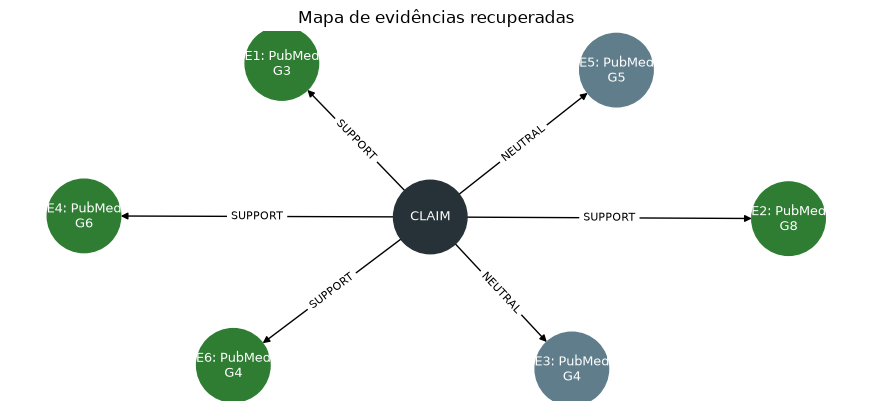

In [18]:
# Visualize um dos mapas; altere o índice para comparar os exemplos.
if demo_results:
    plot_evidence_map(demo_results[0])

## 20 — Métricas da POC

As métricas mostram cobertura e custo operacional do fluxo, não acurácia factual. Uma avaliação real exige um conjunto rotulado por especialistas e critérios prévios.

[{'claim': 'A prática regular de atividade física reduz a mortalidade por todas as causas',
  'status': 'EVIDENCE_SUPPORTS',
  'documents_retrieved': 8,
  'documents_discarded': 0,
  'documents_used': 8,
  'chunks_generated': 44,
  'evidence_used': 6,
  'elapsed_seconds': 27.02,
  'independent_sources_estimated': 8,
  'stance_distribution': {'SUPPORT': 4, 'NEUTRAL': 2}},
 {'claim': 'Tomar café causa câncer',
  'status': 'EVIDENCE_AGAINST',
  'documents_retrieved': 8,
  'documents_discarded': 0,
  'documents_used': 8,
  'chunks_generated': 42,
  'evidence_used': 6,
  'elapsed_seconds': 30.38,
  'independent_sources_estimated': 8,
  'stance_distribution': {'NEUTRAL': 3, 'CONTRADICT': 3}},
 {'claim': 'A suplementação de vitamina D previne infecções respiratórias em todas as pessoas',
  'status': 'EVIDENCE_AGAINST',
  'documents_retrieved': 8,
  'documents_discarded': 0,
  'documents_used': 8,
  'chunks_generated': 49,
  'evidence_used': 6,
  'elapsed_seconds': 23.64,
  'independent_source

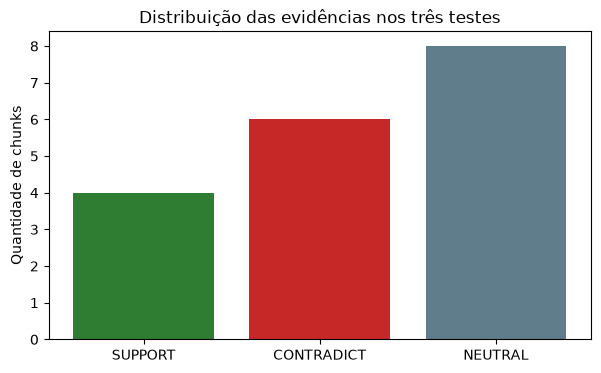

In [19]:
if demo_results:
    metric_rows = [{"claim": r["claim"], "status": r["status"], **r["metrics"]} for r in demo_results]
    display(metric_rows)
    total_stances = Counter(e["stance"] for r in demo_results for e in r["evidence"])
    plt.figure(figsize=(7, 4))
    labels = ["SUPPORT", "CONTRADICT", "NEUTRAL"]
    plt.bar(labels, [total_stances[x] for x in labels], color=["#2e7d32", "#c62828", "#607d8b"])
    plt.title("Distribuição das evidências nos três testes")
    plt.ylabel("Quantidade de chunks")
    plt.show()

## 21 — Limitações

- A busca cobre PubMed e URLs explicitamente configuradas; não representa a web inteira.
- Consultas geradas podem perder sinônimos, idiomas, datas ou fontes relevantes.
- Abstracts não substituem o texto integral nem avaliação do desenho do estudo.
- LLM e NLI cometem erros, especialmente com negação, causalidade, subgrupos e qualificadores.
- A deduplicação é heurística e não comprova independência editorial ou científica.
- Conteúdo pode estar desatualizado, atrás de paywall ou bloquear crawlers.
- A seleção de fontes contém vieses de publicação, idioma e indexação.
- `Evidence Score` é experimental, não calibrado e não é probabilidade de verdade.
- A classificação de meta-análise como “primária” é apenas um sinal de força no protótipo e deve ser refinada por tipo de pergunta.

## 22 — Evolução para o MVP

```text
Next.js → FastAPI → Verification Pipeline → Crawl4AI + APIs oficiais
        → PostgreSQL + pgvector → Hybrid Retrieval → Evidence Analyzer
        → LLM → Trust Report
```

O MVP deve adicionar cache com expiração, filas, observabilidade, política de fontes por domínio, provenance, avaliação humana, versionamento de prompts, testes com corpus rotulado e proteção contra prompt injection presente nas páginas.

Um pipeline futuro e separado poderá analisar URL/domínio:

```text
URL/domínio → Domain Analyzer → HTTPS + metadata + typosquatting
            + brand impersonation + reputação + phishing signals
            → Website Trust Report
```

Essa segunda arquitetura não está implementada nesta POC.